In [13]:
#Find the full coding assesment, write up, and other ML and Data Science projetcs here:
#https://github.com/SiddharthG23/UChicagoDSCode

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## QUESTION 1: EDA

In [45]:
#This is coding assesment I did for a company I was interviewing for. Time limit was 2 hours.
#Goal is to review a fake companies financials and see what we can find out about their revenue growth 

#Step 1 EDA
df = pd.read_csv('IP_transactions_data.csv') #importing data

In [46]:
df.dtypes

CUSTOMER_ID             int64
TRANSACTION_PERIOD     object
REVENUE               float64
CUSTOMER_TYPE          object
YEAR                    int64
PROFIT                float64
IS_TREATMENT_FLAG      object
dtype: object

In [63]:
#Changing Transaction Period to Datetime so we can preform computations on it
df['TRANSACTION_PERIOD'] = pd.to_datetime(df['TRANSACTION_PERIOD'], errors = 'coerce')
#df.dtypes

In [48]:
#Splitting the Dataset into Treatment and Non-Treatment Data
#The "Treatment" group indicates data points collected after the company released 
#a new product bundle as an, so we will do our EDA seperatley for without Treatment and 
dfNoTreat = df[df['IS_TREATMENT_FLAG'].isna()]
#Cleaning Data
dfNoTreat = df.drop('IS_TREATMENT_FLAG', axis = 1)
dfNoTreat.dropna(inplace= True)

In [49]:
dfTreat = df[df['IS_TREATMENT_FLAG'].notna()]

In [50]:
#Function to compute standard statistics
def desc_stats(df):
    print("")
    print("")
    print(df.name)
    print("")
    i = 0
    while (i < len(df.columns)):
        if (df[df.columns[i]].dtypes != object):
            print(df.columns[i], "Range: (Min)",df[df.columns[i]].min(),"(Max)",df[df.columns[i]].max())
            print(df.columns[i], "Average:", df[df.columns[i]].mean(skipna=True))
            print(df.columns[i], "Standard Deviation:", df[df.columns[i]].std())
            print("")
        i +=1

    
df.name = "Whole Dataset"
dfNoTreat.name = "No Treatment Instances"
dfTreat.name = "Treatment Datapoints"   
desc_stats(df)
desc_stats(dfNoTreat)
desc_stats(dfTreat)



Whole Dataset

CUSTOMER_ID Range: (Min) 0 (Max) 29303
CUSTOMER_ID Average: 9549.92167557458
CUSTOMER_ID Standard Deviation: 7893.673687394928

TRANSACTION_PERIOD Range: (Min) 2015-03-31 00:00:00 (Max) 2021-12-31 00:00:00
TRANSACTION_PERIOD Average: 2019-11-10 07:34:08.091776512
TRANSACTION_PERIOD Standard Deviation: 613 days 02:44:18.652834608

REVENUE Range: (Min) -246.62271970466512 (Max) 158841.5070502088
REVENUE Average: 107.75821388535932
REVENUE Standard Deviation: 522.2425297966153

YEAR Range: (Min) 2015 (Max) 2021
YEAR Average: 2019.217538285768
YEAR Standard Deviation: 1.6639058734698589

PROFIT Range: (Min) -121.82205241354198 (Max) 332.565423094293
PROFIT Average: 41.642370949520405
PROFIT Standard Deviation: 31.362644417232



No Treatment Instances

CUSTOMER_ID Range: (Min) 0 (Max) 19906
CUSTOMER_ID Average: 6205.332694337347
CUSTOMER_ID Standard Deviation: 5237.863394917709

TRANSACTION_PERIOD Range: (Min) 2015-03-31 00:00:00 (Max) 2020-12-31 00:00:00
TRANSACTION_PERIO

In [51]:
#based on the previous output we can see that profit needs to be 
#computed by adding together all the profits within a transaction period
dfProfit = dfNoTreat.groupby(['TRANSACTION_PERIOD'])["PROFIT"].sum()
dfProfit

TRANSACTION_PERIOD
2015-03-31     35322.410653
2015-06-30     39508.287572
2015-09-30     44812.297737
2015-12-31     51484.339499
2016-03-31     67946.764611
2016-06-30     76957.363629
2016-09-30     82078.221129
2016-12-31     93783.616355
2017-03-31    111181.523327
2017-06-30    120629.320699
2017-09-30    135753.376221
2017-12-31    157773.052234
2018-03-31    151980.520310
2018-06-30    168639.255620
2018-09-30    186350.308729
2018-12-31    204245.720156
2019-03-31    247298.458457
2019-06-30    276483.173694
2019-09-30    281118.661717
2019-12-31    292064.239525
2020-03-31    263059.516392
2020-06-30    261726.929043
2020-09-30    260388.516452
2020-12-31    256074.838387
Name: PROFIT, dtype: float64

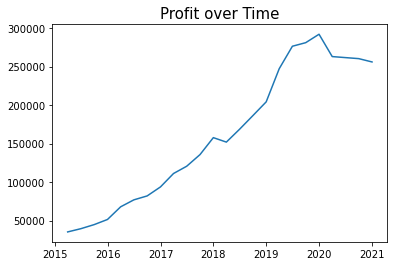

In [52]:
plt.title('Profit over Time', size = 15)
plt.plot(dfProfit)

In [53]:
#We need to do the same for revenue 
dfRevenue = dfNoTreat.groupby(['TRANSACTION_PERIOD'])["REVENUE"].sum()
#dfRevenue #Commented for space

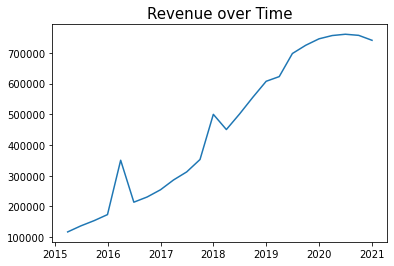

In [54]:
plt.title('Revenue over Time', size = 15)
plt.plot(dfRevenue)

In [55]:
#Find the unique number of customers per transaction period 
dfCust = dfNoTreat.groupby(['TRANSACTION_PERIOD'])["CUSTOMER_ID"].nunique()
dfCust

TRANSACTION_PERIOD
2015-03-31    1095
2015-06-30    1188
2015-09-30    1277
2015-12-31    1361
2016-03-31    1449
2016-06-30    1539
2016-09-30    1615
2016-12-31    1701
2017-03-31    1899
2017-06-30    2110
2017-09-30    2422
2017-12-31    2833
2018-03-31    3285
2018-06-30    3776
2018-09-30    4306
2018-12-31    4876
2019-03-31    5427
2019-06-30    5960
2019-09-30    6478
2019-12-31    6929
2020-03-31    7308
2020-06-30    7700
2020-09-30    8033
2020-12-31    8271
Name: CUSTOMER_ID, dtype: int64

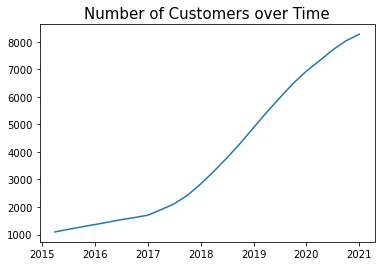

In [56]:
plt.title('Number of Customers over Time', size = 15)
plt.plot(dfCust)

### Conclusion
After cleaning the data by adjusting variable types, removing null datapoints, and splitting the data into experimental and practical data, I did some brief data analysis. What I found is that IP is a generally healthy company over the past 6 years with increasing profits, revenues,and customers (as shown by the graphs above).

However, they did see a very slight decline in customer over the past couple of years and an even greater decrease in revenue growth and profit growth. Revenue actualy plataued, then slighlty decreased over the past year, while profits have decreased over teh past couple of years. It's important to note that as we look at the company over the entire time series it seems like these recent losses may due to negative externalities from something like the pandemic.


## QUESTION 2

In [57]:
# Objective of question 2 is to understand what is driving the company’s annual growth rate across new revenue, 
#churn, upsell and downsell.
ChurnDf = dfNoTreat.groupby('CUSTOMER_ID')['YEAR'].max()
#ChurnDf now has the last year of each customer

In [58]:
#Add this data back to our overall data frame
dfNoTreat = pd.merge(dfNoTreat, ChurnDf, how="left", on = ['CUSTOMER_ID'])

In [60]:
#We now have the transaction year (Year_x) and the last year they were a customer (Year_y) in our df
dfNoTreat.loc[dfNoTreat['CUSTOMER_ID'] == 0]

,CUSTOMER_ID,TRANSACTION_PERIOD,REVENUE,CUSTOMER_TYPE,YEAR_x,PROFIT,YEAR_y
1079,0,2015-03-31,139.460266,Education,2015,46.154152,2015
2058,0,2015-06-30,136.065304,Education,2015,56.085945,2015
2671,0,2015-09-30,140.879896,Education,2015,40.350149,2015


In [61]:
#Make a new column with their churn year
dfNoTreat['CHURNYEAR']=dfNoTreat['YEAR_y'] + 1

In [62]:
grouped = dfNoTreat.groupby('CHURNYEAR')

In [26]:
#CHURN RESULTS
#Add up all the revenue churned (essentially lost)
# Example: A customer who spent $200 in 2019 but has churned in 2020 will result in $200 churned in 2020
grouped.apply(lambda x: x[x['YEAR_x'] == x['YEAR_y']]['REVENUE'].sum())

CHURNYEAR
2016    1.251407e+04
2017    2.416317e+04
2018    2.203056e+05
2019    5.102428e+05
2020    9.542969e+05
2021    3.014942e+06
dtype: float64

In [27]:
#Now we do the same for new customer sales
#First find out what year they were new customers
NewDf = dfNoTreat.groupby('CUSTOMER_ID')['YEAR_x'].min()

In [28]:
dfNoTreat = pd.merge(dfNoTreat, NewDf, how="left", on = ['CUSTOMER_ID'])

In [30]:
dfNoTreat = dfNoTreat.rename(columns={"YEAR_x_x": "YEAR", "YEAR_y": "LAST_YEAR", "YEAR_x_y": "FIRST_YEAR"})

In [31]:
grouped = dfNoTreat.groupby('FIRST_YEAR')

In [32]:
#NEW CUSTOMER RESULTS
grouped.apply(lambda x: x[x['YEAR'] == x['FIRST_YEAR']]['REVENUE'].sum())

FIRST_YEAR
2015    5.814460e+05
2016    1.060769e+05
2017    4.236061e+05
2018    7.139582e+05
2019    1.013212e+06
2020    1.234395e+06
dtype: float64

In [33]:
sell = dfNoTreat.groupby(['YEAR','CUSTOMER_ID'])['REVENUE'].sum()

In [34]:
sell

YEAR  CUSTOMER_ID
2015  0              416.405467
      1              526.048539
      2              400.161864
      3              437.719921
      4              409.699027
                        ...    
2020  19902           68.536828
      19903           82.437174
      19904           88.676051
      19905           48.129934
      19906           79.767918
Name: REVENUE, Length: 35375, dtype: float64

In [35]:
#Computing upsell and downsell for each year 
# A customer who spent $100 in 2019 and $150 in 2020 will result in a $50 upsell in 2020
#A customer who spent $100 in 2019 and $75 in 2020 will result in a $25 downsell in 2020
YearsDF = [dfNoTreat[dfNoTreat['YEAR'] == y] for y in dfNoTreat['YEAR'].unique()]

In [44]:
for i in range(len(YearsDF)):
    YearsDF[i] = YearsDF[i].groupby(['CUSTOMER_ID'])['REVENUE'].sum()

In [53]:
YearDiffs = [] #Store results
for i in range (len(YearsDF)-1):
    diff = YearsDF[i].subtract(YearsDF[i + 1],fill_value=0)
    YearDiffs.append(diff)
    
Y1516,Y1617,Y1718,Y1819,Y1920 = YearDiffs

In [55]:
YearDiffsDict = {
    "1516": Y1516,
    "1617": Y1617,
    "1718": Y1718,
    "1819": Y1819,
    "1920": Y1920,}

SumResults = {}

for year, diff in YearDiffsDict.items():
    SumResults[f"sum_pos{year}"] = diff[diff > 0].sum()
    SumResults[f"sum_neg{year}"] = diff[diff < 0].sum()

for i, v in SumResults.items():
    print(f"{i}: {v}")


sum_pos1516: 19676.24044138504
sum_neg1516: -487843.10599266214
sum_pos1617: 250569.8460000027
sum_neg1617: -652514.6000871672
sum_pos1718: 432845.72654631693
sum_neg1718: -1095773.0151847494
sum_pos1819: 740436.9642562189
sum_neg1819: -1417081.1729288518
sum_pos1920: 1343956.28948135
sum_neg1920: -1567769.6117826714


## QUESTION 3

In [50]:

dfTreat

,CUSTOMER_ID,TRANSACTION_PERIOD,REVENUE,CUSTOMER_TYPE,YEAR,PROFIT,IS_TREATMENT_FLAG
92838,21611,2021-03-31,116.199564,Education,2021,NaN,True
92839,21582,2021-03-31,77.837372,Education,2021,NaN,False
92840,21598,2021-03-31,65.198867,Tech,2021,NaN,True
92841,21520,2021-03-31,98.413748,Education,2021,NaN,False
92842,10038,2021-03-31,48.745408,Tech,2021,NaN,False
...,...,...,...,...,...,...,...
127768,27550,2021-12-31,113.332621,Education,2021,NaN,True
127769,27549,2021-12-31,106.615109,Education,2021,NaN,True
127770,27548,2021-12-31,104.878460,Education,2021,NaN,True
127771,27547,2021-12-31,102.230067,Education,2021,NaN,True


In [51]:
TestC = dfTreat.groupby(['IS_TREATMENT_FLAG'])['REVENUE'].count()
print("Count", TestC)
print("")
TestS = dfTreat.groupby(['IS_TREATMENT_FLAG'])['REVENUE'].sum()
print("Sum", TestS)
print("")
TestA = dfTreat.groupby(['IS_TREATMENT_FLAG'])['REVENUE'].mean()
print("Average", TestA)

Count IS_TREATMENT_FLAG
False    17380
True     17554
Name: REVENUE, dtype: int64

Sum IS_TREATMENT_FLAG
False    1.376996e+06
True     1.390072e+06
Name: REVENUE, dtype: float64

Average IS_TREATMENT_FLAG
False    79.228742
True     79.188338
Name: REVENUE, dtype: float64
